In [39]:
import pandas as pd
import json
import numpy as np
import mitsuba as mi
import drjit as dr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
from datetime import datetime

# # 設定 Mitsuba3 變體
# mi.set_variant("cuda_ad_mono_polarized")

import sionna.rt
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, \
                      PathSolver, r_hat, PolarizedAntennaPattern, \
                      register_antenna_pattern, AntennaPattern, RadioMapSolver, Camera
from PIL import Image

Directivity [dB]: 19.1
Gain [dB]: -9.68e-05
Efficiency [%]: 1.22


(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 2 Axes>)

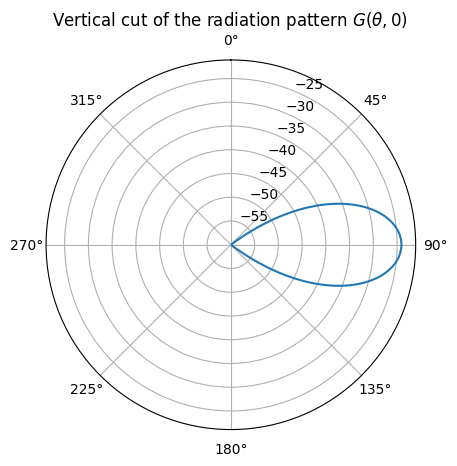

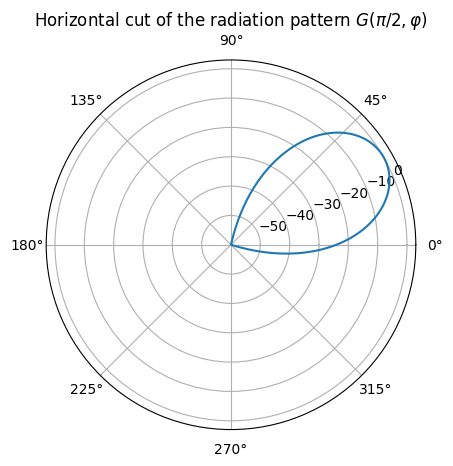

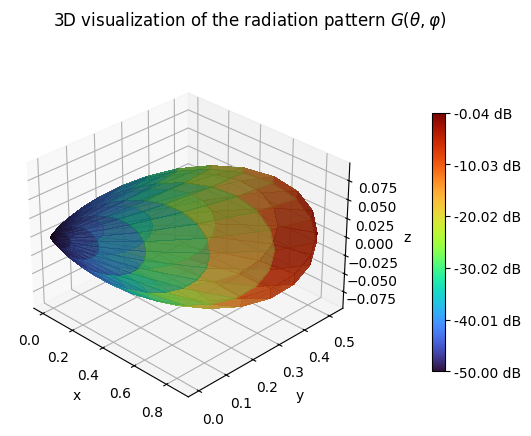

In [40]:
import mitsuba as mi
import drjit as dr
import numpy as np
from sionna.rt import AntennaPattern, PlanarArray, register_antenna_pattern

def elliptical_beam_pattern_func(theta: mi.Float, phi: mi.Float, 
                                  theta_0: float, phi_0: float,
                                  theta_width: float, phi_width: float) -> mi.Complex2f:
    """
    橢圓波束場型函數
    
    參數:
        theta: 天頂角
        phi: 方位角
        theta_0: 主波束天頂角方向 (弧度)
        phi_0: 主波束方位角方向 (弧度)
        theta_width: theta 方向的波束寬度參數 (弧度)
        phi_width: phi 方向的波束寬度參數 (弧度)
    """
    # 計算相對於主波束方向的角度偏移
    delta_theta = theta - theta_0
    delta_phi = phi - phi_0
    
    # 處理 phi 的週期性 (-π 到 π)
    delta_phi = dr.atan2(dr.sin(delta_phi), dr.cos(delta_phi))
    
    # 使用高斯函數，只在主波束方向有峰值
    amplitude = dr.exp(-0.5 * ((delta_theta / theta_width)**2 + 
                                (delta_phi / phi_width)**2))
    
    return mi.Complex2f(amplitude, 0)

class EllipticalBeamPattern(AntennaPattern):
    def __init__(self, theta_0=90.0, phi_0=0.0, 
                 theta_beamwidth=30.0, phi_beamwidth=60.0):
        """
        參數:
            theta_0: 主波束天頂角方向 (度)
            phi_0: 主波束方位角方向 (度)
            theta_beamwidth: theta 方向半功率波束寬度 (度)
            phi_beamwidth: phi 方向半功率波束寬度 (度)
        """
        theta_0_rad = np.deg2rad(theta_0)
        phi_0_rad = np.deg2rad(phi_0)
        # 將波束寬度轉換為高斯函數的標準差
        theta_width = np.deg2rad(theta_beamwidth) / 2.355
        phi_width = np.deg2rad(phi_beamwidth) / 2.355
        
        def my_pattern(theta, phi):
            """返回 (c_theta, c_phi)"""
            c_theta = elliptical_beam_pattern_func(theta, phi, 
                                                   theta_0_rad, phi_0_rad,
                                                   theta_width, phi_width)
            c_phi = dr.zeros(mi.Complex2f, dr.width(c_theta))
            return c_theta, c_phi
        
        # 建立 patterns 屬性
        self.patterns = [my_pattern]

def elliptical_beam_factory(theta_0=90.0, phi_0=0.0, 
                            theta_beamwidth=30.0, phi_beamwidth=60.0):
    """工廠函數"""
    return EllipticalBeamPattern(theta_0, phi_0, 
                                 theta_beamwidth, phi_beamwidth)

# 註冊天線場型
register_antenna_pattern("elliptical_beam", elliptical_beam_factory)

# 主波束水平方向，theta 窄 (20°)，phi 寬 (60°)
array = PlanarArray(num_rows=1, num_cols=1, 
                   pattern="elliptical_beam",
                   theta_0=90,           # 主波束水平
                   phi_0=30.0,              # 方位角 0°
                   theta_beamwidth=30.0,   # theta 方向窄
                   phi_beamwidth=30.0)     # phi 方向寬

array.antenna_pattern.compute_gain()
array.antenna_pattern.show()

In [41]:
def carla_to_sionna_orientation(yaw, pitch, roll):
    """
    將CARLA的旋轉轉換為Sionna的方向
    
    Parameters:
    -----------
    yaw : float
        CARLA的yaw角度（度）
    pitch : float
        CARLA的pitch角度（度）
    roll : float
        CARLA的roll角度（度）
    
    Returns:
    --------
    list : [sionna_yaw, sionna_pitch, sionna_roll] in radians
    
    轉換規則（根據實測結果）：
    CARLA: pitch=-20.0, yaw=-110.0, roll=50.0
    Sionna: yaw=-1.9199, pitch=0.3491, roll=-0.8727
    """
    # Sionna的yaw = CARLA的yaw轉弧度
    sionna_yaw = np.radians(yaw)  # -110° → -1.9199 rad
    
    # Sionna的pitch = -CARLA的pitch轉弧度（符號相反）
    sionna_pitch = -np.radians(pitch)  # -(-20°) = 20° → 0.3491 rad
    
    # Sionna的roll = -CARLA的roll轉弧度（符號相反）
    sionna_roll = -np.radians(roll)  # -(50°) = -50° → -0.8727 rad
    
    return [float(sionna_yaw), float(sionna_pitch), float(sionna_roll)]

In [42]:
scene_name="../my_scene/nycu_carla_v7_add_plane_yf_mirror/nycu_carla_v7_add_plane_yf_mirror.xml"
scene = load_scene(scene_name)
print("set material...")
scene.frequency=28e9
# new_material = ITURadioMaterial("new_material",
#                                 "concrete",
#                                thinkness=0.1)
new_material = sionna.rt.RadioMaterial(f"my_material_{scene.frequency}",
                            relative_permittivity=5.24,
                            conductivity=0.0462*(scene.frequency/1e9)**0.7822,
                            scattering_pattern='lambertian')
for i, obj in enumerate(scene.objects.values()):
    scene.get(obj.name).radio_material=new_material
print("set material success")

set material...
set material success


In [43]:
scene.preview();

In [66]:
tx_position=(340, 80, 12)

refraction_flag=True
diffraction_flag=True
edge_diffraction_flag=True

#carla orientation
# pitch=-20.0, yaw=-110.0, roll=0.0
orientation=carla_to_sionna_orientation(yaw=-110.0, pitch=0, roll=0.0)

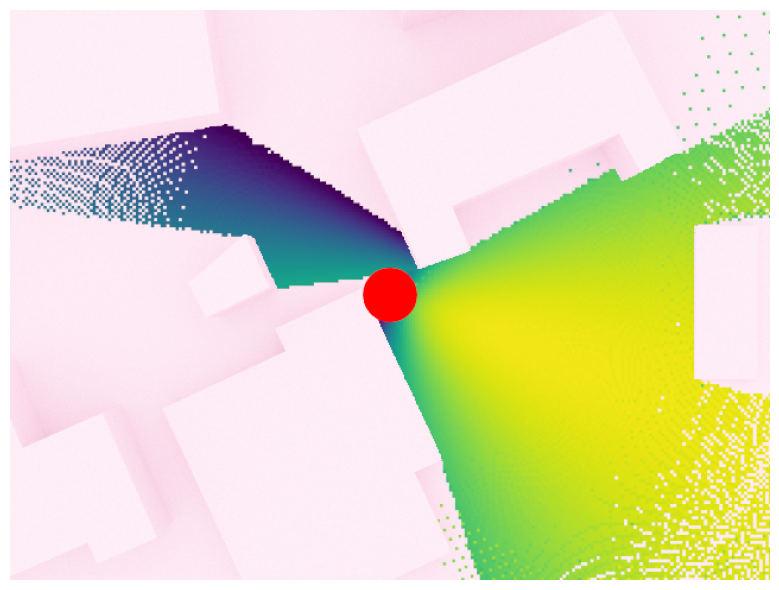

In [79]:
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, 
                   pattern="elliptical_beam",
                   theta_0=90,           # 主波束水平
                   phi_0=0,              # 方位角 0°
                   theta_beamwidth=30.0,   # theta 方向窄
                   phi_beamwidth=30.0) 
scene.remove("tx0")
tx0 = Transmitter(name='tx0',
                          position=[tx_position[0], tx_position[1], tx_position[2]],
                  orientation=orientation
)
scene.add(tx0)

solver = RadioMapSolver()
rm = solver(scene, cell_size=(1., 1.), max_depth=1)
# scene.preview(radio_map=rm)
my_cam = Camera(position=[340, 80, 300], look_at=[340,80,0])



scene.render(camera=my_cam, resolution=[640, 480], radio_map=rm, num_samples=512);


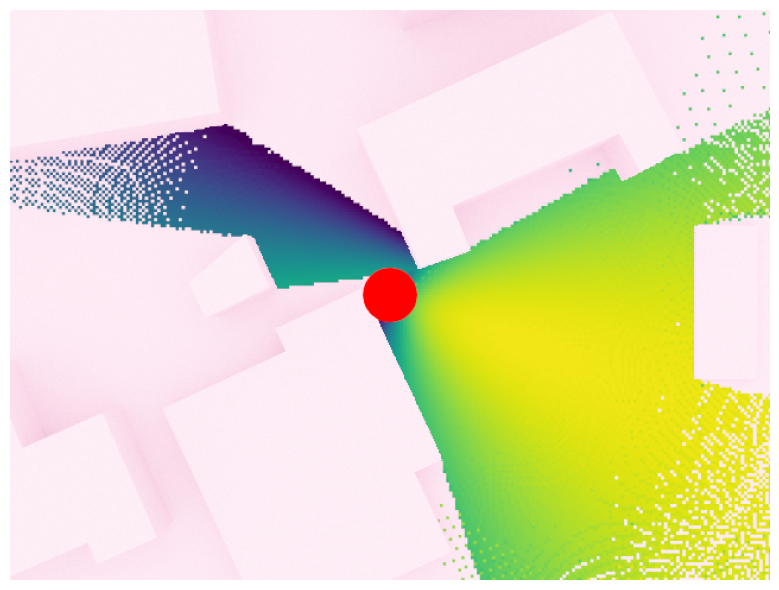

In [62]:
img=scene.render(camera=my_cam, resolution=[640, 480], radio_map=rm, num_samples=512);
img.canvas.draw()
image_array = np.array(img.canvas.buffer_rgba())
# 移除 alpha 通道，只保留 RGB
image_array = image_array[:, :, :3]
flipped_array = np.fliplr(image_array)
img = Image.fromarray(flipped_array) # PIL image
img.show()

In [80]:
test_dict={"id": "hhh", "pos": 123}

if hasattr(test_dict, "id"):
    print(test_dict[id])


In [84]:
import numpy as np

class RSUAngleCalculator:
    def __init__(self, rsu_position, reference_rx_position):
        """
        初始化 RSU 角度計算器
        
        Parameters:
        -----------
        rsu_position : list or array
            RSU 的位置 [x, y, z]（只用前兩個）
        reference_rx_position : list or array
            參考 rx 的位置（用來定義 RSU 的正前方）
        """
        self.rsu_pos = np.array(rsu_position[:2])
        
        # 計算 RSU 的正前方向
        ref_pos = np.array(reference_rx_position[:2])
        forward_vector = ref_pos - self.rsu_pos
        self.forward_angle = np.arctan2(forward_vector[1], forward_vector[0])
        
    def calculate_angle(self, rx_position):
        """
        計算 rx 相對於 RSU 正前方的夾角
        
        Parameters:
        -----------
        rx_position : list or array
            rx 的位置 [x, y, z]
            
        Returns:
        --------
        angle_deg : float
            相對角度（度），範圍 -180 到 180
            正值 = 右側，負值 = 左側
        """
        rx_pos = np.array(rx_position[:2])
        
        # 計算從 rsu 指向 rx 的向量角度
        vector_to_rx = rx_pos - self.rsu_pos
        angle_to_rx = np.arctan2(vector_to_rx[1], vector_to_rx[0])
        
        # 計算相對角度
        relative_angle = angle_to_rx - self.forward_angle
        
        # 標準化到 [-π, π]
        relative_angle = np.arctan2(np.sin(relative_angle), np.cos(relative_angle))
        
        return np.degrees(relative_angle)


# 使用範例
rsu_position = [340.0, 80.0, 12.0]
rx_40_position = [292.1495666503906, -45.17396545410156, 0.0]

# 初始化計算器（用 rx_40 定義正前方）
calculator = RSUAngleCalculator(rsu_position, rx_40_position)

# 測試 rx_40（應該是 0°）
angle = calculator.calculate_angle(rx_40_position)
print(f"rx_40 相對於 rsu 正前方的夾角: {angle:.2f}°")

# 測試其他位置
test_positions = [
    [313.0, 54.0, 0.0],    
    [291.0, 42.0, 0.0],  
    [267.0, 29.0, 0.0], 
    [273, -12, 0],
    [304, -66, 0],
    [319, -94, 0],
    [334, -121, 0]
]

for pos in test_positions:
    angle = calculator.calculate_angle(pos)
    print(f"位置 {pos[:2]} 的夾角: {angle:.2f}°")

rx_40 相對於 rsu 正前方的夾角: 0.00°
位置 [313.0, 54.0] 的夾角: -25.16°
位置 [291.0, 42.0] 的夾角: -31.29°
位置 [267.0, 29.0] 的夾角: -34.14°
位置 [273, -12] 的夾角: -15.14°
位置 [304, -66] 的夾角: 7.07°
位置 [319, -94] 的夾角: 14.04°
位置 [334, -121] 的夾角: 19.21°
